# Abstract
An end-to-end classification workflow to predict EV purchasing behavior and identify the primary demographic and vehicle features influencing buyer decisions.

In [1]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub


/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e9/train.csv
/kaggle/input/competitions/playground-series-s6e9/test.csv


# I. Importing Data and Exploratory Data Analysis

In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/train.csv')
train_df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
train_df.shape

(668665, 15)

In [4]:
train_df.describe() 

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.00000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.00000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.10321,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.00000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.00000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.00000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.00000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.00000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [5]:
# Checking null count
null_counts = train_df.isnull().sum()
print(null_counts)

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64


From the above two steps we get to know that the dataset doesn't have any null data or invalid data. So there is no necessity of Imputations or Data Cleaning

In [6]:
# Checking categorical data
object_cols = list(train_df.select_dtypes(include = ['object']).columns)
print(object_cols)

['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV']


In [7]:
# Calculate the percentage of people who purchased EV
percentages = train_df['Will_Buy_EV'].value_counts(normalize=True) * 100

yes_percentage = percentages.get('Yes', 0)

print(f"Percentage of People who purchased EV: {yes_percentage:.2f}%")

Percentage of People who purchased EV: 17.46%


As the data is not severely imbalanced, we can proceed with ROC-AUC metric for validating model further ahead

In [8]:
# Detect Cardinality
for col in object_cols:
    num_unique = train_df[col].nunique()
    print(f"{col}\t{num_unique}")

Gender	3
City_Type	3
Current_Car_Type	4
Home_Charging_Possible	2
Subsidy_Available	2
Range_Anxiety_Level	3
Will_Buy_EV	2


As the dataset has low cardinality, we will proceed with One Hot Encoding for fitting the categorical data

In [9]:
# Declaring test data frame
test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/test.csv')

In [10]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (668665, 15)
Test shape: (286571, 14)


# II. Separating Features and Target
Target column according to problem statement is Will_Buy_EV

In [11]:
X = train_df.drop(columns=['Will_Buy_EV'])
y = train_df['Will_Buy_EV'].map({
    'Yes': 1,
    'No': 0
})

X_test = test_df.copy()

# III. Identify Numerical and Categorical Data

In [12]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("\nNumerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)


Numerical columns:
['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

Categorical columns:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


From the initial analysis of data, consisting of around 668k observations, we get sufficient indicators (demographic, behavioral, economic, infrastructure) to detect the driving factors of the trend and reasonably make further predictions.

# IV. Train Validation Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# V. One Hot Encoding Categorical Data

In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_cols]
)

X_val_cat = encoder.transform(
    X_val[categorical_cols]
)

X_test_cat = encoder.transform(
    X_test[categorical_cols]
)

# VI. Get numerical Features

In [15]:
X_train_num = X_train[numeric_cols].to_numpy()
X_val_num = X_val[numeric_cols].to_numpy()
X_test_num = X_test[numeric_cols].to_numpy()

# VII. Combine Numerical and Categorical Data

In [16]:
X_train_final = np.hstack([
    X_train_num,
    X_train_cat
])

X_val_final = np.hstack([
    X_val_num,
    X_val_cat
])

X_test_final = np.hstack([
    X_test_num,
    X_test_cat
])

print("\nFinal training shape:", X_train_final.shape)
print("Final validation shape:", X_val_final.shape)
print("Final test shape:", X_test_final.shape)


Final training shape: (534932, 25)
Final validation shape: (133733, 25)
Final test shape: (286571, 25)


# VIII. Implementing XGBoostClassifier Model

In [17]:
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=5,

    objective='binary:logistic',
    eval_metric='auc',

    random_state=42,
    n_jobs=-1
)

# IX. Train

In [18]:
model.fit(
    X_train_final,
    y_train,

    eval_set=[
        (X_val_final, y_val)
    ],

    verbose=100
)

[0]	validation_0-auc:0.93288
[100]	validation_0-auc:0.93981
[200]	validation_0-auc:0.94086
[300]	validation_0-auc:0.94134
[400]	validation_0-auc:0.94153
[500]	validation_0-auc:0.94164
[600]	validation_0-auc:0.94168
[700]	validation_0-auc:0.94168
[800]	validation_0-auc:0.94168
[900]	validation_0-auc:0.94165
[999]	validation_0-auc:0.94164


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

# X. Validation ROC - AUC

In [19]:
y_val_pred = model.predict_proba(
    X_val_final
)[:, 1]

roc_auc = roc_auc_score(
    y_val,
    y_val_pred
)

print(
    f"\nValidation ROC-AUC: {roc_auc:.5f}"
)


Validation ROC-AUC: 0.94164


# XI. Feature Importance

In [20]:
feature_names = (
    numeric_cols +
    encoder.get_feature_names_out(categorical_cols).tolist()
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 20 features:")
display(importance_df.head(20))


Top 20 features:


,Feature,Importance
20,Subsidy_Available_No,0.527570
7,Environmental_Concern_Level,0.198560
21,Subsidy_Available_Yes,0.195971
23,Range_Anxiety_Level_Low,0.030821
24,Range_Anxiety_Level_Medium,0.010304
2,Annual_Income_USD,0.009535
22,Range_Anxiety_Level_High,0.003549
18,Home_Charging_Possible_No,0.002868
19,Home_Charging_Possible_Yes,0.001988
3,Daily_Commute_km,0.001709


/tmp/ipykernel_16/2289169948.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


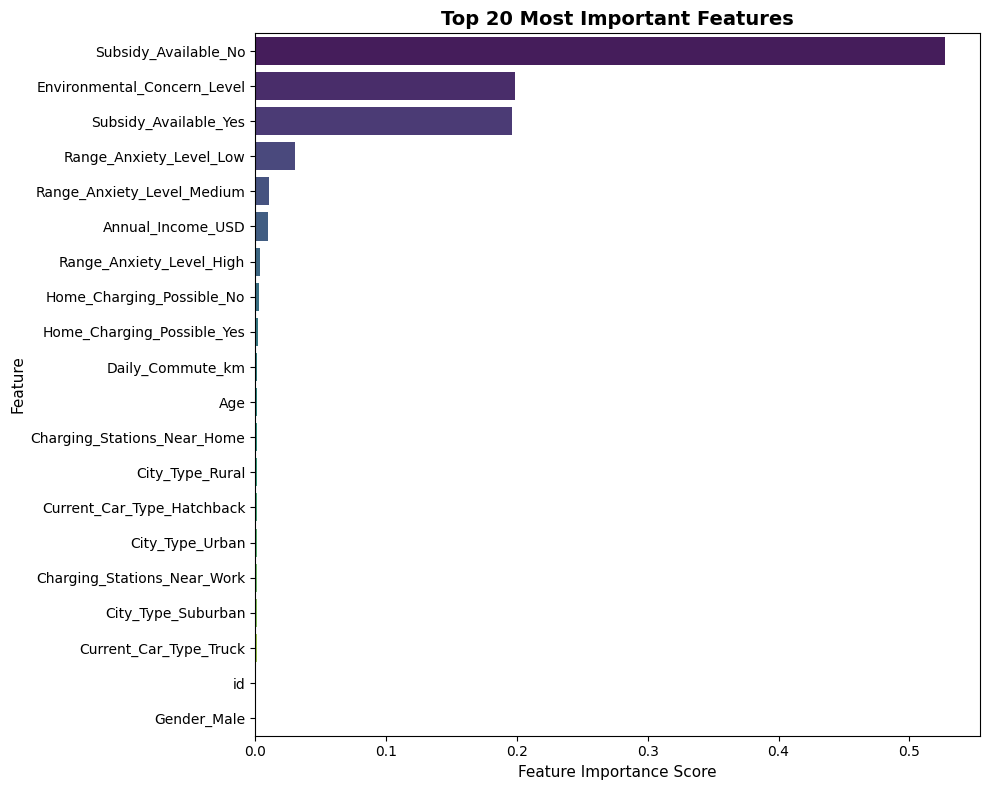

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 20 features
top_20 = importance_df.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_20,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 20 Most Important Features", fontsize=14, weight="bold")
plt.xlabel("Feature Importance Score", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.tight_layout()
plt.show()

The model achieved a ROC-AUC of 0.94164. Interestingly, the model's predictive power was heavily concentrated around subsidy availability and environmental concern, suggesting that policy incentives and environmental attitudes may be substantially more informative than basic demographics in this dataset.

# XII. Train final model on training data

In [22]:
X_full_cat = encoder.fit_transform(
    X[categorical_cols]
)

X_test_cat = encoder.transform(
    X_test[categorical_cols]
)

X_full_num = X[numeric_cols].to_numpy()
X_test_num = X_test[numeric_cols].to_numpy()

X_full_final = np.hstack([
    X_full_num,
    X_full_cat
])

X_test_final = np.hstack([
    X_test_num,
    X_test_cat
])

# XIII. Final Model

In [23]:
final_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=5,

    objective='binary:logistic',
    eval_metric='auc',

    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_full_final,
    y,
    verbose=100
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

# XIV. Test Predictions

In [24]:
test_predictions = final_model.predict_proba(
    X_test_final
)[:, 1]

# XV. Submission

In [25]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'Will_Buy_EV': test_predictions
})

submission.to_csv(
    '/kaggle/working/submission.csv',
    index=False
)

print("\nSubmission created:")
display(submission.head())


Submission created:


,id,Will_Buy_EV
0,668665,0.013766
1,668666,0.014069
2,668667,0.004006
3,668668,0.004814
4,668669,0.014303


# Conclusion

**The Analysis of EV purchase training dataset points to a pattern where majority of the trend is driven by availability of subsidies and environmental concerns. The demographic and infrastructure related indicators contribute comparitively less in predictive operation. This indicates that financial incentives and customer attitudes may be particularly important levers for EV adoption and can potentially be used to identify high-propensity customers for targeted EV campaigns.**